# From Barriers to Policy Priorities

## Purpose

The preceding notebooks established data integrity, documented patterns of financial inclusion, and explored barriers faced by excluded adults. This notebook synthesizes those findings into a decision focused framework.

The objective is to identify which constraints are most strongly associated with formal account ownership after accounting for socioeconomic characteristics, and to translate these findings into policy relevant priorities that remain useful in 2026 and beyond.

**Policy Relevance:** This analysis will help policymakers prioritize interventions by identifying the most significant barriers to financial inclusion and suggesting targeted solutions based on socioeconomic characteristics.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP: Professional Theme, Libraries & Helpers
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ─── COLOR PALETTE ────────────────────────────────────────────────────────
COLORS = {
    'primary': '#1B4F72', 'secondary': '#2E86C1', 'accent': '#E67E22',
    'success': '#27AE60', 'danger': '#C0392B', 'warning': '#F39C12',
    'light': '#F8F9FA', 'dark': '#2C3E50', 'muted': '#5D6D7E',
    'bg': '#FAFBFC', 'grid': '#E8ECF0', 'text': '#2C3E50',
}
PALETTE_CAT = ['#1B4F72', '#2E86C1', '#27AE60', '#E67E22', '#C0392B', '#8E44AD', '#F39C12']

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'], 'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'], 'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'], 'grid.alpha': 0.6, 'grid.linewidth': 0.5,
    'figure.figsize': (14, 7), 'font.size': 11, 'axes.titlesize': 16,
    'axes.labelsize': 12, 'figure.titlesize': 18, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'figure.dpi': 120,
})

def weighted_mean(series, weights):
    valid = ~series.isna() & ~weights.isna()
    if valid.sum() == 0: return np.nan
    return np.average(series[valid], weights=weights[valid])

def weighted_std(series, weights):
    valid = series.notna() & weights.notna()
    mean = weighted_mean(series, weights)
    return np.sqrt(np.average((series[valid] - mean) ** 2, weights=weights[valid]))

def add_source_note(fig, extra=""):
    txt = "Source: World Bank Global Findex 2024 — Malawi Microdata (n = 1,000; survey-weighted)"
    if extra: txt += f"\n{extra}"
    fig.text(0.02, -0.02, txt, fontsize=10, color=COLORS['muted'], fontstyle='italic', ha='left', va='top')

def styled_table(data, title="", bar_col=None, precision=1):
    styler = data.style.set_caption(title).set_table_styles([
        {'selector': 'caption', 'props': [('font-size','14px'),('font-weight','bold'),
            ('color', COLORS['primary']),('text-align','left'),('padding-bottom','8px')]},
        {'selector': 'thead th', 'props': [('background-color', COLORS['primary']),('color','white'),
            ('font-weight','bold'),('text-align','center'),('padding','8px 12px'),
            ('border-bottom', f'2px solid {COLORS["accent"]}')]},
        {'selector': 'tbody td', 'props': [('text-align','center'),('padding','6px 12px'),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody th', 'props': [('text-align','left'),('padding','6px 12px'),
            ('font-weight','500'),('background-color', COLORS['light']),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': '', 'props': [('border-collapse','collapse'),('width','100%')]},
    ]).format(precision=precision)
    if bar_col and bar_col in data.columns:
        styler = styler.bar(subset=[bar_col], color=COLORS['secondary'], vmin=0)
    return styler

def kpi_cards(metrics):
    cards = ""
    for label, value, icon, color in metrics:
        cards += f"""<div style="flex:1;min-width:140px;background:white;border-radius:12px;
            padding:18px 16px;text-align:center;box-shadow:0 2px 12px rgba(0,0,0,0.06);
            border-top:4px solid {color};margin:6px;">
            <div style="font-size:28px;margin-bottom:4px;">{icon}</div>
            <div style="font-size:28px;font-weight:800;color:{color};letter-spacing:-0.5px;">{value}</div>
            <div style="font-size:12px;color:#4a5568;margin-top:4px;line-height:1.3;">{label}</div>
        </div>"""
    display(HTML(f"""<div style="display:flex;flex-wrap:wrap;gap:8px;justify-content:center;
        padding:10px 0;max-width:900px;margin:auto;">{cards}</div>"""))

print("✅ Professional theme loaded")

✅ Professional theme loaded


## Data preparation

This notebook loads raw Findex microdata directly. To ensure analytical consistency with previous notebooks, all derived variables used in the decision analysis are explicitly reconstructed here using documented Findex coding conventions.

No variables are assumed to exist unless they are verified.

In [2]:
DATA_PATH = "../data/raw/Findex_Microdata_2025_updateMalawi.csv"
df = pd.read_csv(DATA_PATH)
kpi_cards([
    ("Respondents", f"{df.shape[0]:,}", "👥", COLORS['primary']),
    ("Variables", f"{df.shape[1]}", "📊", COLORS['secondary']),
])

In [3]:
# ─── Core validation & gender recode ──────────────────────────────────────
required = ["account_fin", "wgt", "educ", "inc_q", "female"]
missing = [v for v in required if v not in df.columns]
if missing: raise KeyError(f"Missing: {missing}")

# ⚠️ GENDER RECODE (in-place, irreversible within this notebook)
# Raw Findex coding: female=1 (Female), female=2 (Male)
# Regression coding: female=1 (Female), female=0 (Male)
# NB00-03 use the RAW coding (1/2). Only NB04 uses this binary recode.
df["female"] = (df["female"] == 1).astype(int)

display(HTML(f"""<div style="max-width:700px;margin:auto;padding:12px 20px;border-radius:10px;
    background:white;border-left:4px solid {COLORS['success']};box-shadow:0 1px 8px rgba(0,0,0,0.05);
    font-size:12px;">
    ✅ Core variables validated &nbsp;|&nbsp; Gender recoded: <b>1 = Female</b>, <b>0 = Male</b><br>
    Female: {df['female'].sum():,} &nbsp;|&nbsp; Male: {(df['female']==0).sum():,}
</div>"""))

## Barrier Variables Preparation

For policy analysis, we examine barriers to financial inclusion from the Global Findex survey.

**Bank account barriers (fin11a–f):** Asked only to respondents **without a bank account** (excluding those with mobile money only).
- fin11a: Financial institutions too far away
- fin11b: Financial services too expensive
- fin11c: Lack necessary documentation
- fin11d: Don't have enough money to use an account
- fin11e: Family member already has an account
- fin11f: Don't trust financial institutions

**Mobile money barriers (fin14a–e):** Asked only to respondents **without a mobile money account** (Sub-Saharan Africa only).
- fin14a: Mobile money agents too far away
- fin14b: Mobile money products too expensive
- fin14c: Lack necessary documentation
- fin14d: Don't have enough money
- fin14e: Worried about safety/security of money

> **⚠ Selection Bias:** Barrier questions are *conditional on exclusion* — only asked to those who lack the relevant account type. This means barrier variables are structurally correlated with non-ownership by survey design. Regression coefficients must be interpreted as associations **within the at-risk population**, not as causal effects on the general population.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# BARRIER VARIABLES — Per Global Findex 2024 Codebook
# ═══════════════════════════════════════════════════════════════════════════════

bank_barriers = {
    'fin11a': 'Too far away', 'fin11b': 'Too expensive', 'fin11c': 'Lack documentation',
    'fin11d': 'Lack money', 'fin11e': 'Family member has account', 'fin11f': 'Lack trust',
}
mobile_barriers = {
    'fin14a': 'Agents too far', 'fin14b': 'Too expensive', 'fin14c': 'Lack documentation',
    'fin14d': 'Lack of money', 'fin14e': 'Security/safety worries',
}

# ─── Availability tables ─────────────────────────────────────────────────
rows = []
for src, bdict in [('Bank (fin11)', bank_barriers), ('Mobile (fin14)', mobile_barriers)]:
    for var, label in bdict.items():
        n_valid = df[var].isin([1, 2]).sum() if var in df.columns else 0
        n_yes = (df[var] == 1).sum() if var in df.columns else 0
        rows.append({'Source': src, 'Variable': var, 'Label': label,
                     'Valid N': n_valid, 'Cited (Yes)': n_yes})
display(styled_table(pd.DataFrame(rows).set_index('Variable'),
                     '📋 Raw Barrier Variable Availability'))

# ─── Note ─────────────────────────────────────────────────────────────────
display(HTML(f"""<div style="max-width:800px;margin:10px auto;padding:14px 20px;border-radius:10px;
    background:#FEF9E7;border-left:4px solid {COLORS['warning']};font-size:12px;">
    ⚠️ <b>Bank barriers (fin11a–f) have zero valid responses</b> in Malawi — nearly all adults
    without a bank account have mobile money, so the survey routed them to fin14 instead.<br>
    All composite barrier variables derive <em>exclusively</em> from mobile-money barriers (fin14a–e, ~409 respondents).
</div>"""))

# ─── Composite indicators ────────────────────────────────────────────────
df['barrier_distance']  = ((df.get('fin11a', 0) == 1) | (df.get('fin14a', 0) == 1)).astype(int)
df['barrier_cost']      = ((df.get('fin11b', 0) == 1) | (df.get('fin14b', 0) == 1)).astype(int)
df['barrier_document']  = ((df.get('fin11c', 0) == 1) | (df.get('fin14c', 0) == 1)).astype(int)
df['barrier_trust']     = ((df.get('fin11f', 0) == 1) | (df.get('fin14e', 0) == 1)).astype(int)
df['barrier_no_money']  = ((df.get('fin11d', 0) == 1) | (df.get('fin14d', 0) == 1)).astype(int)

barrier_vars = ['barrier_distance', 'barrier_cost', 'barrier_document',
                'barrier_trust', 'barrier_no_money']
pretty_barrier_names = {
    'barrier_distance': 'Distance / Access', 'barrier_cost': 'Cost / Expense',
    'barrier_document': 'Documentation', 'barrier_trust': 'Trust / Security',
    'barrier_no_money': 'Lack of Money',
}

comp_rows = []
for var in barrier_vars:
    n = df[var].sum(); pct = n / len(df) * 100
    comp_rows.append({'Barrier': pretty_barrier_names[var], 'Affected (n)': n, 'Prevalence (%)': pct})
display(styled_table(pd.DataFrame(comp_rows).set_index('Barrier'),
                     '🧩 Composite Barrier Indicators', bar_col='Prevalence (%)'))

,Source,Label,Valid N,Cited (Yes)
Variable,,,,
fin11a,Bank (fin11),Too far away,0,0
fin11b,Bank (fin11),Too expensive,0,0
fin11c,Bank (fin11),Lack documentation,0,0
fin11d,Bank (fin11),Lack money,0,0
fin11e,Bank (fin11),Family member has account,0,0
fin11f,Bank (fin11),Lack trust,0,0
fin14a,Mobile (fin14),Agents too far,409,54
fin14b,Mobile (fin14),Too expensive,406,115
fin14c,Mobile (fin14),Lack documentation,409,135


,Affected (n),Prevalence (%)
Barrier,,
Distance / Access,54,5.4
Cost / Expense,115,11.5
Documentation,135,13.5
Trust / Security,116,11.6
Lack of Money,321,32.1


In [5]:
# ─── Analysis dataset ─────────────────────────────────────────────────────
analysis_vars = ["account_fin", "account", "female", "educ", "inc_q", "wgt"] + barrier_vars
model_df = df[analysis_vars].dropna()

kpi_cards([
    ("Analysis N", f"{model_df.shape[0]:,}", "📐", COLORS['primary']),
    ("Formal Rate", f"{model_df['account_fin'].mean()*100:.1f}%", "🏦", COLORS['secondary']),
    ("Any-Account Rate", f"{model_df['account'].mean()*100:.1f}%", "💳", COLORS['success']),
    ("Predictors", f"{len(barrier_vars) + 3}", "🔢", COLORS['accent']),
])

## Descriptive Statistics: Financial Inclusion by Demographics

Before modeling, let's examine the basic patterns of financial inclusion across different socioeconomic groups.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# DESCRIPTIVE: Financial Inclusion Rates (Weighted)
# ═══════════════════════════════════════════════════════════════════════════════

formal_rate = weighted_mean(model_df["account_fin"], model_df["wgt"]) * 100
any_rate    = weighted_mean(model_df["account"],     model_df["wgt"]) * 100

female_mask = model_df["female"] == 1; male_mask = model_df["female"] == 0
female_rate = weighted_mean(model_df.loc[female_mask, "account_fin"], model_df.loc[female_mask, "wgt"]) * 100
male_rate   = weighted_mean(model_df.loc[male_mask,   "account_fin"], model_df.loc[male_mask,   "wgt"]) * 100
female_any  = weighted_mean(model_df.loc[female_mask, "account"],     model_df.loc[female_mask, "wgt"]) * 100
male_any    = weighted_mean(model_df.loc[male_mask,   "account"],     model_df.loc[male_mask,   "wgt"]) * 100
gender_gap  = male_rate - female_rate

kpi_cards([
    ("Formal Account", f"{formal_rate:.1f}%", "🏦", COLORS['primary']),
    ("Any Account", f"{any_rate:.1f}%", "💳", COLORS['success']),
    ("Female (formal)", f"{female_rate:.1f}%", "♀️", COLORS['accent']),
    ("Male (formal)", f"{male_rate:.1f}%", "♂️", COLORS['secondary']),
    ("Gender Gap", f"{gender_gap:+.1f}pp", "📏", COLORS['danger']),
])

tbl = pd.DataFrame([
    {'Group': 'All',    'Formal (%)': formal_rate, 'Any (%)': any_rate},
    {'Group': 'Female', 'Formal (%)': female_rate, 'Any (%)': female_any},
    {'Group': 'Male',   'Formal (%)': male_rate,   'Any (%)': male_any},
])
display(styled_table(tbl.set_index('Group'), '📊 Account Ownership Rates by Gender'))

,Formal (%),Any (%)
Group,,
All,12.4,50.4
Female,9.5,46.4
Male,15.6,54.8


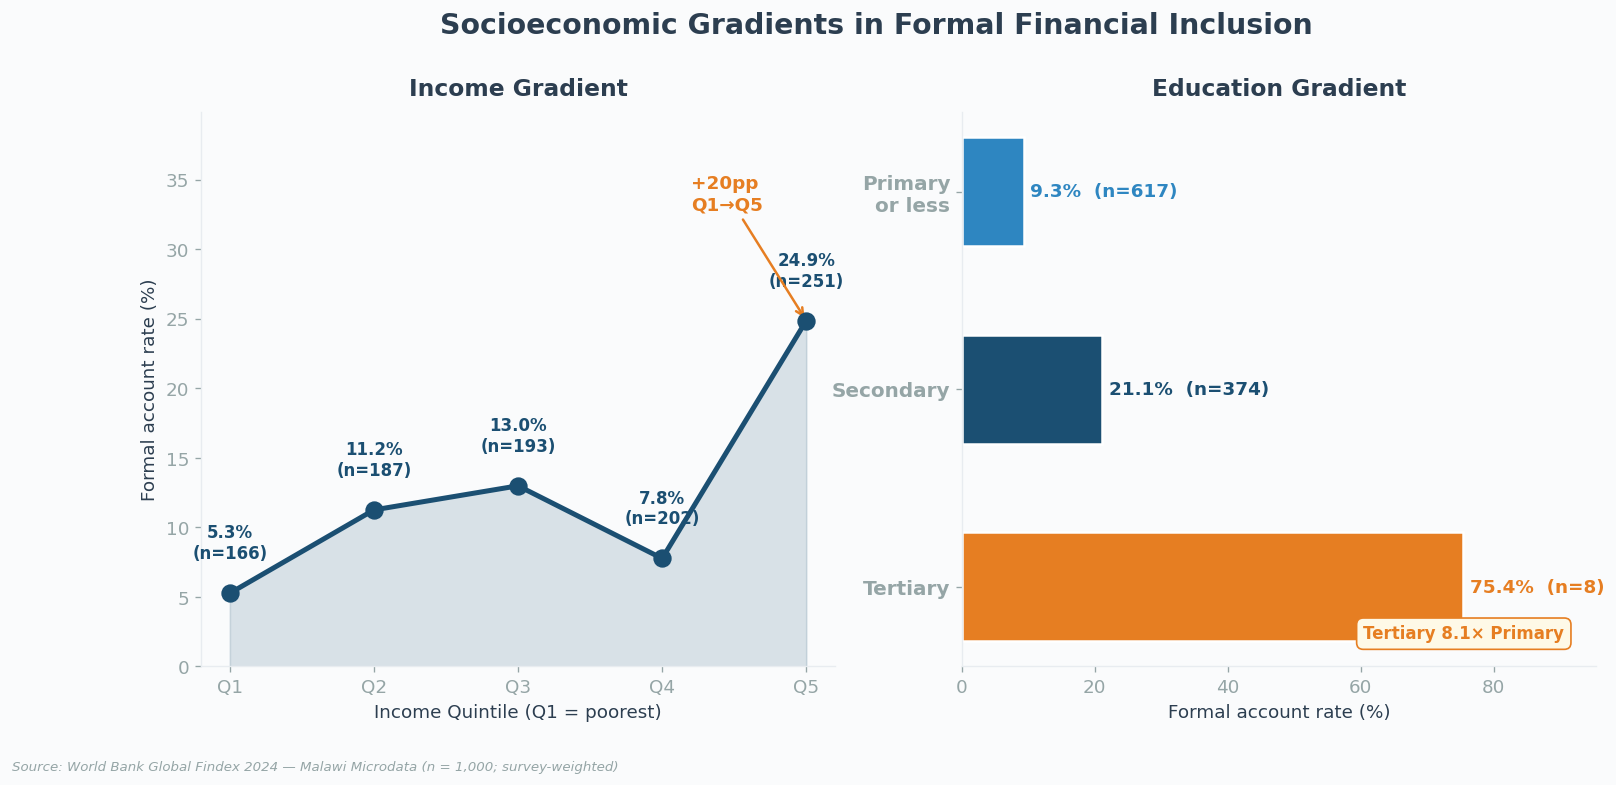

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE — Income & Education Gradients  (2 panels)
# ═══════════════════════════════════════════════════════════════════════════════

income_summary = (model_df.groupby("inc_q")
    .apply(lambda x: weighted_mean(x["account_fin"], x["wgt"]) * 100)
    .reset_index(name="rate"))
income_summary["n"] = model_df["inc_q"].value_counts().sort_index().values

educ_summary = (model_df.groupby("educ")
    .apply(lambda x: weighted_mean(x["account_fin"], x["wgt"]) * 100)
    .reset_index(name="rate"))
educ_labels = {1: "Primary\nor less", 2: "Secondary", 3: "Tertiary"}
educ_summary["label"] = educ_summary["educ"].map(educ_labels)
educ_summary["n"] = model_df["educ"].value_counts().sort_index().values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel 1: Income gradient (area + line) ───────────────────────────────
ax1.fill_between(income_summary["inc_q"], income_summary["rate"],
                 alpha=0.15, color=COLORS['primary'])
ax1.plot(income_summary["inc_q"], income_summary["rate"], 'o-',
         color=COLORS['primary'], linewidth=3, markersize=10, zorder=5)
for _, r in income_summary.iterrows():
    ax1.text(r["inc_q"], r["rate"] + 2.5, f'{r["rate"]:.1f}%\n(n={int(r["n"])})',
             ha='center', fontsize=10, fontweight='bold', color=COLORS['primary'])
ax1.set_xticks(range(1, 6))
ax1.set_xticklabels([f'Q{i}' for i in range(1, 6)], fontsize=11)
ax1.set_xlabel('Income Quintile (Q1 = poorest)', fontsize=11)
ax1.set_ylabel('Formal account rate (%)', fontsize=11)
ax1.set_ylim(0, max(income_summary["rate"]) + 15)
ax1.set_title('Income Gradient', fontsize=14, fontweight='bold', pad=10)

# gap annotation
gap_inc = income_summary.iloc[-1]["rate"] - income_summary.iloc[0]["rate"]
ax1.annotate(f'+{gap_inc:.0f}pp\nQ1→Q5', xy=(5, income_summary.iloc[-1]["rate"]),
             xytext=(4.2, income_summary.iloc[-1]["rate"] + 8),
             fontsize=11, fontweight='bold', color=COLORS['accent'],
             arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

# ── Panel 2: Education gradient (horizontal bars) ────────────────────────
y_pos = np.arange(len(educ_summary))
cols = [COLORS['secondary'], COLORS['primary'], COLORS['accent']]
for i, (_, r) in enumerate(educ_summary.iterrows()):
    ax2.barh(i, r["rate"], height=0.55, color=cols[i], edgecolor='white', linewidth=1.5)
    ax2.text(r["rate"] + 1, i, f'{r["rate"]:.1f}%  (n={int(r["n"])})',
             va='center', fontsize=11, fontweight='bold', color=cols[i])
ax2.set_yticks(y_pos)
ax2.set_yticklabels(educ_summary["label"], fontsize=12, fontweight='bold')
ax2.set_xlabel('Formal account rate (%)', fontsize=11)
ax2.set_xlim(0, max(educ_summary["rate"]) + 20)
ax2.set_title('Education Gradient', fontsize=14, fontweight='bold', pad=10)
ax2.invert_yaxis()

ratio = educ_summary.iloc[-1]["rate"] / max(educ_summary.iloc[0]["rate"], 0.01)
ax2.text(0.95, 0.05, f'Tertiary {ratio:.1f}× Primary', transform=ax2.transAxes,
         ha='right', fontsize=10, fontweight='bold', color=COLORS['accent'],
         bbox=dict(boxstyle='round,pad=0.4', fc='#FEF9E7', ec=COLORS['accent']))

fig.suptitle('Socioeconomic Gradients in Formal Financial Inclusion',
             fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig)
plt.savefig('../outputs/figures/gradients.png', bbox_inches='tight', dpi=200)
plt.show()

## Barrier Analysis: Prevalence of Different Barriers

Before multivariate analysis, let's examine the prevalence of each barrier in the population.

,Prevalence (%)
Barrier,
Lack of Money,35.9
Documentation,15.3
Trust / Security,12.6
Cost / Expense,11.9
Distance / Access,6.4


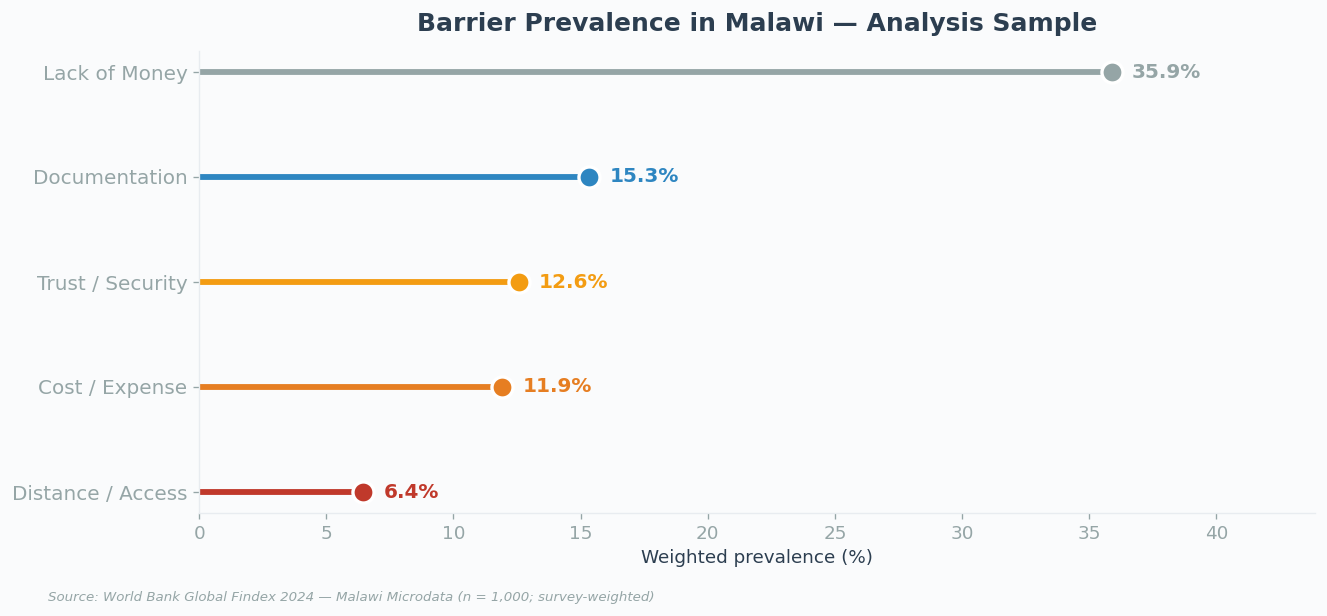

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# BARRIER PREVALENCE — Styled Table + Lollipop Chart
# ═══════════════════════════════════════════════════════════════════════════════

barrier_prev = []
for bvar in barrier_vars:
    prev = weighted_mean(model_df[bvar], model_df["wgt"]) * 100
    barrier_prev.append({'Barrier': pretty_barrier_names.get(bvar, bvar),
                         'Variable': bvar, 'Prevalence (%)': prev})
barrier_df = pd.DataFrame(barrier_prev).sort_values('Prevalence (%)', ascending=False)

display(styled_table(barrier_df.set_index('Barrier')[['Prevalence (%)']],
                     '🚧 Barrier Prevalence in Analysis Sample', bar_col='Prevalence (%)'))

# ─── Lollipop chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_b = barrier_df.sort_values('Prevalence (%)', ascending=True)
y_pos = np.arange(len(sorted_b))
pal = [COLORS['danger'], COLORS['accent'], COLORS['warning'], COLORS['secondary'], COLORS['muted']]

for i, (_, row) in enumerate(sorted_b.iterrows()):
    ax.plot([0, row['Prevalence (%)']], [i, i], color=pal[i], linewidth=3.5, solid_capstyle='round')
    ax.scatter(row['Prevalence (%)'], i, s=160, color=pal[i], zorder=5,
              edgecolors='white', linewidth=2)
    ax.text(row['Prevalence (%)'] + 0.8, i, f"{row['Prevalence (%)']:.1f}%",
            va='center', fontsize=12, fontweight='bold', color=pal[i])

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_b['Barrier'], fontsize=12)
ax.set_xlim(0, sorted_b['Prevalence (%)'].max() + 8)
ax.set_xlabel('Weighted prevalence (%)', fontsize=11)
ax.set_title('Barrier Prevalence in Malawi — Analysis Sample',
             fontsize=15, fontweight='bold', pad=12)
add_source_note(fig)
plt.savefig('../outputs/figures/barrier_prevalence_policy.png', bbox_inches='tight', dpi=200)
plt.show()

## Multivariate Analysis: Logistic Regression

Now we'll use logistic regression to identify which barriers remain significant predictors of account ownership after controlling for socioeconomic characteristics.

In [9]:
# ============================================================================
# LOGISTIC REGRESSION — Survey-Weighted, Dual-Outcome
# ============================================================================

regression_df = model_df.copy()
predictors = ['female', 'educ', 'inc_q'] + barrier_vars

# ── Check for zero-variance predictors ───────────────────────────────────
print("Checking predictor variance...")
zero_variance_vars = []
for var in predictors:
    n_unique = regression_df[var].nunique()
    print(f"  {var:20} {n_unique} unique values")
    if n_unique < 2:
        zero_variance_vars.append(var)

if zero_variance_vars:
    print(f"\n⚠ Excluding zero-variance: {', '.join(zero_variance_vars)}")
    predictors = [v for v in predictors if v not in zero_variance_vars]
    barrier_vars_clean = [v for v in barrier_vars if v not in zero_variance_vars]
else:
    barrier_vars_clean = barrier_vars.copy()

# ── Model 1: Formal Account (account_fin) — Weighted ────────────────────
formula = 'account_fin ~ ' + ' + '.join(predictors)
print(f"\n{'='*65}")
print("MODEL 1 — Formal Account Ownership (account_fin)")
print(f"{'='*65}")
print(f"Formula: {formula}")
print("Fitting survey-weighted logistic regression (freq_weights = wgt)...\n")

try:
    logit_model = sm.Logit.from_formula(
        formula, data=regression_df,
        freq_weights=regression_df['wgt'].values
    )
    result = logit_model.fit(disp=1, maxiter=100)

    print(f"\n✓ Model 1 converged!")
    print(f"  Pseudo R² (McFadden): {result.prsquared:.4f}")
    print(f"  Log-Likelihood:       {result.llf:.2f}")
    print(f"  AIC:                  {result.aic:.2f}")
    print(f"  Observations:         {int(result.nobs)}")
    print(f"  Predictors:           {len(predictors)} ({len(barrier_vars_clean)} barriers)")
except Exception as e:
    print(f"\n✗ REGRESSION FAILED: {e}")
    raise

# ── Model 2: Any Account (account) — Weighted ───────────────────────────
formula_any = 'account ~ ' + ' + '.join(predictors)
print(f"\n{'='*65}")
print("MODEL 2 — Any Account Ownership (account)")
print(f"{'='*65}")
print(f"Formula: {formula_any}")
print("Fitting survey-weighted logistic regression...\n")

try:
    logit_model_any = sm.Logit.from_formula(
        formula_any, data=regression_df,
        freq_weights=regression_df['wgt'].values
    )
    result_any = logit_model_any.fit(disp=0, maxiter=100)

    print(f"✓ Model 2 converged!")
    print(f"  Pseudo R² (McFadden): {result_any.prsquared:.4f}")
    print(f"  Log-Likelihood:       {result_any.llf:.2f}")
    print(f"  AIC:                  {result_any.aic:.2f}")
except Exception as e:
    print(f"  Model 2 failed: {e}")
    result_any = None

# ── Selection Bias Caveat ────────────────────────────────────────────────
print(f"\n{'='*65}")
print("⚠  INTERPRETING BARRIER COEFFICIENTS")
print("-" * 65)
print("""Barrier questions are only asked to people WITHOUT the relevant
account type. This creates structural endogeneity:

• A positive OR on a barrier does NOT mean the barrier helps inclusion.
  It means: among people asked about barriers (the excluded), those
  who cited THIS barrier were more likely to ALSO have the other type
  of account (e.g., a bank account despite lacking mobile money).

• Marginal effects are more interpretable than raw odds ratios for
  understanding the practical magnitude of associations.

• These results identify CORRELATES of exclusion, not causal drivers.
""")

Checking predictor variance...
  female               2 unique values
  educ                 3 unique values
  inc_q                5 unique values
  barrier_distance     2 unique values
  barrier_cost         2 unique values
  barrier_document     2 unique values
  barrier_trust        2 unique values
  barrier_no_money     2 unique values

MODEL 1 — Formal Account Ownership (account_fin)
Formula: account_fin ~ female + educ + inc_q + barrier_distance + barrier_cost + barrier_document + barrier_trust + barrier_no_money
Fitting survey-weighted logistic regression (freq_weights = wgt)...



Optimization terminated successfully.
         Current function value: 0.368643
         Iterations 7

✓ Model 1 converged!
  Pseudo R² (McFadden): 0.1212
  Log-Likelihood:       -368.27
  AIC:                  754.55
  Observations:         999
  Predictors:           8 (5 barriers)

MODEL 2 — Any Account Ownership (account)
Formula: account ~ female + educ + inc_q + barrier_distance + barrier_cost + barrier_document + barrier_trust + barrier_no_money
Fitting survey-weighted logistic regression...

✓ Model 2 converged!
  Pseudo R² (McFadden): 0.4474
  Log-Likelihood:       -380.76
  AIC:                  779.53

⚠  INTERPRETING BARRIER COEFFICIENTS
-----------------------------------------------------------------
Barrier questions are only asked to people WITHOUT the relevant
account type. This creates structural endogeneity:

• A positive OR on a barrier does NOT mean the barrier helps inclusion.
  It means: among people asked about barriers (the excluded), those
  who cited THIS bar

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# REGRESSION RESULTS — Styled Odds-Ratio Tables
# ═══════════════════════════════════════════════════════════════════════════════

def format_results(res, model_label):
    tbl = pd.DataFrame({
        'Variable': res.params.index, 'Coef': res.params.values,
        'SE': res.bse.values, 'p-value': res.pvalues.values,
    })
    tbl['OR'] = np.exp(tbl['Coef'])
    tbl['OR Lower'] = np.exp(tbl['Coef'] - 1.96 * tbl['SE'])
    tbl['OR Upper'] = np.exp(tbl['Coef'] + 1.96 * tbl['SE'])
    tbl['Sig'] = tbl['p-value'].apply(
        lambda p: '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else '.' if p < .1 else '')
    return tbl

results_summary = format_results(result, "Formal Account")

# pretty display
disp1 = results_summary[['Variable','OR','OR Lower','OR Upper','p-value','Sig']].copy()
disp1['Variable'] = disp1['Variable'].map(lambda v: pretty_barrier_names.get(v, v.replace('_',' ').title()))

display(styled_table(
    disp1.set_index('Variable').round(3),
    '📈 Model 1 — Formal Account (account_fin) · Odds Ratios', precision=3))

if result_any is not None:
    results_any_summary = format_results(result_any, "Any Account")
    disp2 = results_any_summary[['Variable','OR','OR Lower','OR Upper','p-value','Sig']].copy()
    disp2['Variable'] = disp2['Variable'].map(lambda v: pretty_barrier_names.get(v, v.replace('_',' ').title()))
    display(styled_table(
        disp2.set_index('Variable').round(3),
        '📈 Model 2 — Any Account (account) · Odds Ratios', precision=3))

# ─── Side-by-side comparison ─────────────────────────────────────────────
if result_any is not None:
    compare_rows = []
    for bvar in barrier_vars:
        name = pretty_barrier_names.get(bvar, bvar)
        r1 = results_summary.loc[results_summary['Variable'] == bvar]
        r2 = results_any_summary.loc[results_any_summary['Variable'] == bvar]
        if len(r1) and len(r2):
            compare_rows.append({'Barrier': name,
                                 'OR (Formal)': r1['OR'].values[0],
                                 'OR (Any)': r2['OR'].values[0],
                                 'p (Formal)': r1['p-value'].values[0],
                                 'p (Any)': r2['p-value'].values[0]})
    if compare_rows:
        display(styled_table(pd.DataFrame(compare_rows).set_index('Barrier').round(3),
                             '⚖️ Side-by-Side: Barrier Odds Ratios', precision=3))

,OR,OR Lower,OR Upper,p-value,Sig
Variable,,,,,
Intercept,0.038,0.018,0.084,0.000,***
Female,0.661,0.456,0.958,0.029,*
Educ,1.892,1.319,2.713,0.001,***
Inc Q,1.346,1.166,1.554,0.000,***
Distance / Access,4.638,1.595,13.488,0.005,**
Cost / Expense,0.813,0.288,2.298,0.696,
Documentation,0.837,0.320,2.186,0.716,
Trust / Security,1.205,0.461,3.148,0.704,
Lack of Money,0.190,0.090,0.400,0.000,***


,OR,OR Lower,OR Upper,p-value,Sig
Variable,,,,,
Intercept,0.650,0.327,1.289,0.217,
Female,0.754,0.524,1.085,0.129,
Educ,2.330,1.600,3.393,0.000,***
Inc Q,1.251,1.098,1.425,0.001,***
Distance / Access,3.356,0.998,11.279,0.050,.
Cost / Expense,0.306,0.106,0.882,0.028,*
Documentation,0.284,0.107,0.754,0.012,*
Trust / Security,0.520,0.190,1.424,0.203,
Lack of Money,0.022,0.012,0.042,0.000,***


,OR (Formal),OR (Any),p (Formal),p (Any)
Barrier,,,,
Distance / Access,4.638,3.356,0.005,0.050
Cost / Expense,0.813,0.306,0.696,0.028
Documentation,0.837,0.284,0.716,0.012
Trust / Security,1.205,0.520,0.704,0.203
Lack of Money,0.190,0.022,0.000,0.000


,VIF,Status
Variable,,
educ,5.26,⚠️
inc_q,4.95,✅
barrier_no_money,2.11,✅
female,2.01,✅
barrier_document,1.65,✅
barrier_cost,1.64,✅
barrier_trust,1.62,✅
barrier_distance,1.34,✅


,dy/dx,SE,p-value
Female,-0.0470,0.0214,0.0277
Educ,0.0724,0.0206,0.0004
Inc Q,0.0338,0.0082,0.0000
Distance / Access,0.1744,0.0617,0.0047
Cost / Expense,-0.0235,0.0602,0.6962
Documentation,-0.0203,0.0557,0.7159
Trust / Security,0.0212,0.0557,0.7040
Lack of Money,-0.1886,0.0430,0.0000


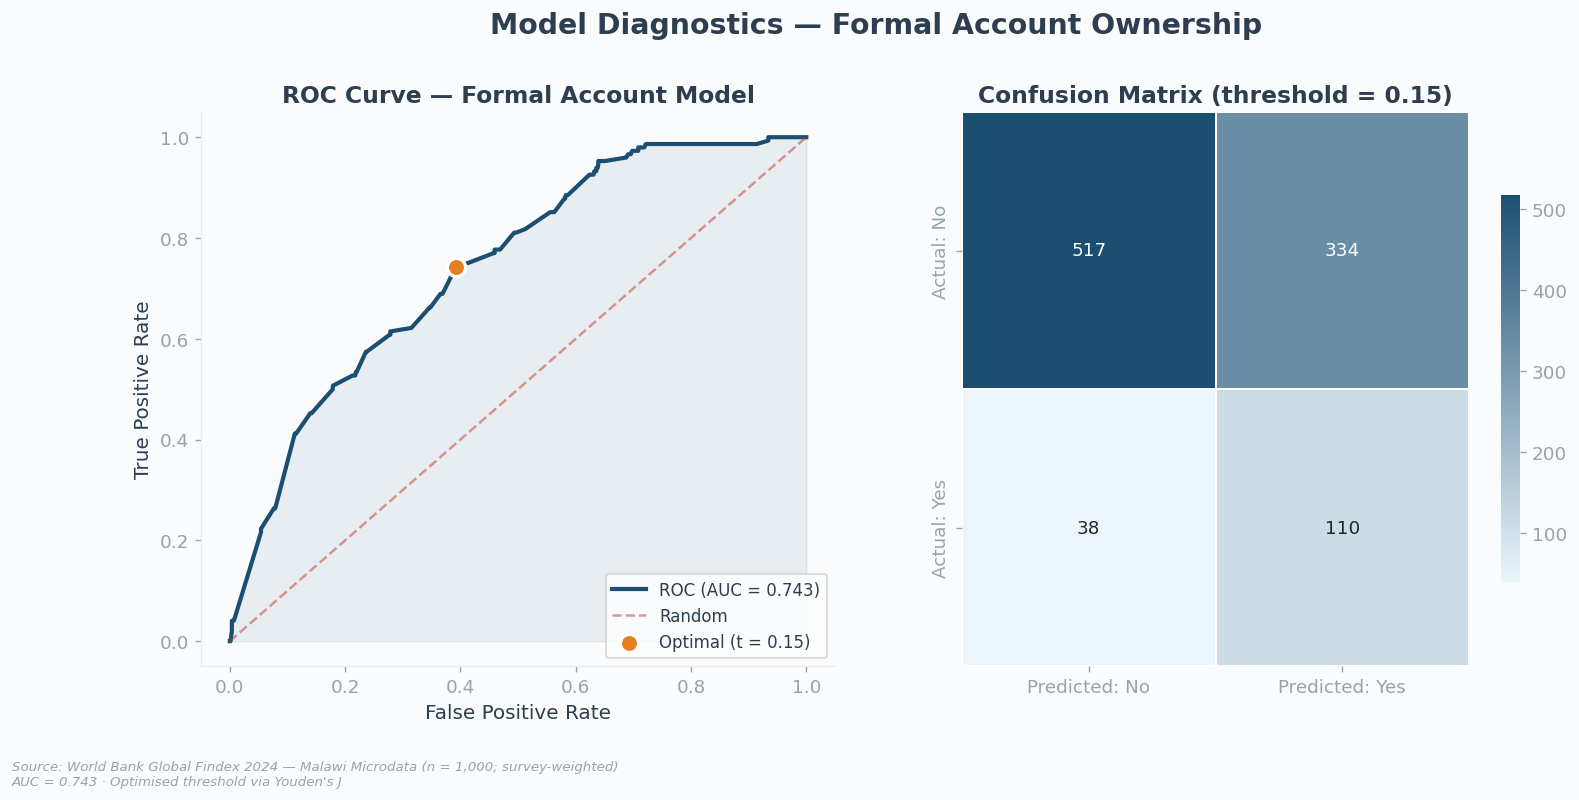

,Accuracy,Precision,Recall,F1
Threshold,,,,
Default (0.50),0.852,0.500,0.020,0.039
Optimised (0.15),0.628,0.248,0.743,0.372


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED MODEL DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════════════

pseudo_r2 = result.prsquared
r2_tag = "Low" if pseudo_r2 < 0.2 else "Moderate" if pseudo_r2 < 0.4 else "Good"

# ─── KPI cards — Model fit ────────────────────────────────────────────────
kpi_cards([
    ("Pseudo R²", f"{pseudo_r2:.4f}", "📐", COLORS['primary']),
    ("AIC", f"{result.aic:.0f}", "📉", COLORS['secondary']),
    ("BIC", f"{result.bic:.0f}", "📊", COLORS['accent']),
    ("Log-Likelihood", f"{result.llf:.0f}", "📈", COLORS['success']),
])

# ─── VIF table ────────────────────────────────────────────────────────────
predictors = ['female', 'educ', 'inc_q'] + barrier_vars
X_vif = model_df[predictors].copy()
# Filter out zero-variance
zero_var = [c for c in X_vif.columns if X_vif[c].nunique() < 2]
predictors_clean = [v for v in predictors if v not in zero_var]
barrier_vars_clean = [v for v in barrier_vars if v not in zero_var]
X_vif = model_df[predictors_clean]

vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif_data['Status'] = vif_data['VIF'].apply(lambda v: '✅' if v < 5 else '⚠️' if v < 10 else '❌')
display(styled_table(vif_data.set_index('Variable'),
                     '🔬 Multicollinearity Check (VIF)', precision=2))

# ─── Marginal effects ────────────────────────────────────────────────────
try:
    mfx = result.get_margeff(at='overall', method='dydx')
    mfx_df = mfx.summary_frame().copy()
    mfx_df.columns = ['dy/dx', 'SE', 'z', 'p-value', 'CI Low', 'CI High']
    mfx_df.index = [pretty_barrier_names.get(v, v.replace('_',' ').title()) for v in mfx_df.index]
    display(styled_table(mfx_df[['dy/dx', 'SE', 'p-value']].round(4),
                         '📊 Average Marginal Effects (dy/dx)', precision=4))
except Exception:
    mfx_df = None

# ─── ROC + Confusion Matrix ──────────────────────────────────────────────
regression_df = model_df.copy()
pred_prob = result.predict(regression_df[predictors_clean])
fpr, tpr, thresholds = roc_curve(regression_df['account_fin'], pred_prob)
auc = roc_auc_score(regression_df['account_fin'], pred_prob)
j_scores = tpr - fpr
best_idx = j_scores.argmax()
best_threshold = thresholds[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── ROC ──────────────────────────────────────────────────────────────────
ax1.fill_between(fpr, tpr, alpha=0.08, color=COLORS['primary'])
ax1.plot(fpr, tpr, color=COLORS['primary'], lw=2.5, label=f'ROC (AUC = {auc:.3f})')
ax1.plot([0, 1], [0, 1], '--', color=COLORS['danger'], alpha=0.5, label='Random')
ax1.scatter(fpr[best_idx], tpr[best_idx], color=COLORS['accent'], s=120, zorder=5,
            edgecolors='white', linewidth=2, label=f'Optimal (t = {best_threshold:.2f})')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Formal Account Model', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white')

# ── Confusion Matrix ────────────────────────────────────────────────────
y_pred = (pred_prob >= best_threshold).astype(int)
cm = confusion_matrix(regression_df['account_fin'], y_pred)
cmap_cm = LinearSegmentedColormap.from_list('cm', ['#EBF5FB', COLORS['primary']])
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_cm, ax=ax2,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.7})
ax2.set_title(f'Confusion Matrix (threshold = {best_threshold:.2f})',
              fontsize=14, fontweight='bold')

fig.suptitle('Model Diagnostics — Formal Account Ownership',
             fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig, f'AUC = {auc:.3f} · Optimised threshold via Youden\'s J')
plt.savefig('../outputs/figures/model_diagnostics.png', bbox_inches='tight', dpi=200)
plt.show()

# ─── Performance at different thresholds ─────────────────────────────────
perf_rows = []
for label, t in [("Default (0.50)", 0.5), (f"Optimised ({best_threshold:.2f})", best_threshold)]:
    yp = (pred_prob >= t).astype(int)
    perf_rows.append({'Threshold': label,
                      'Accuracy': accuracy_score(regression_df['account_fin'], yp),
                      'Precision': precision_score(regression_df['account_fin'], yp, zero_division=0),
                      'Recall': recall_score(regression_df['account_fin'], yp, zero_division=0),
                      'F1': f1_score(regression_df['account_fin'], yp, zero_division=0)})
display(styled_table(pd.DataFrame(perf_rows).set_index('Threshold'),
                     '🎯 Prediction Performance', precision=3))

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTERACTION EFFECTS — Do barriers differ by group?
# ═══════════════════════════════════════════════════════════════════════════════

barriers_str = ' + '.join(barrier_vars_clean)
interaction_rows = []

tests = [
    ('Gender × Cost',      'female',  'barrier_cost',     'female_x_cost'),
    ('Income × Distance',  'inc_q',   'barrier_distance', 'income_x_distance'),
    ('Gender × Lack Money','female',  'barrier_no_money', 'female_x_money'),
]

for label, var1, var2, ixname in tests:
    regression_df[ixname] = regression_df[var1] * regression_df[var2]
    formula_ix = f"account_fin ~ female + educ + inc_q + {barriers_str} + {ixname}"
    try:
        r_ix = sm.Logit.from_formula(formula_ix, data=regression_df,
                                     freq_weights=regression_df['wgt'].values).fit(disp=0)
        coef = r_ix.params[ixname]; pval = r_ix.pvalues[ixname]; or_v = np.exp(coef)
        interaction_rows.append({
            'Interaction': label, 'Coef': coef, 'OR': or_v,
            'p-value': pval, 'Sig': '✅' if pval < 0.05 else '❌',
            'ΔR²': r_ix.prsquared - result.prsquared,
        })
    except Exception as e:
        interaction_rows.append({'Interaction': label, 'Coef': np.nan, 'OR': np.nan,
                                 'p-value': np.nan, 'Sig': '⚠️', 'ΔR²': np.nan})

ix_df = pd.DataFrame(interaction_rows)
display(styled_table(ix_df.set_index('Interaction'),
                     '🔀 Interaction Effect Tests', precision=4))

# ─── Interpretation card ─────────────────────────────────────────────────
n_sig = ix_df['Sig'].eq('✅').sum()
msg = ("Non-significant interactions → <b>universal interventions</b> are appropriate; "
       "barriers affect groups similarly.") if n_sig == 0 else (
       f"{n_sig} significant interaction(s) → consider <b>tailored interventions</b> by group.")
display(HTML(f"""<div style="max-width:750px;margin:10px auto;padding:14px 20px;border-radius:10px;
    background:white;border-left:4px solid {COLORS['secondary']};font-size:12px;
    box-shadow:0 1px 8px rgba(0,0,0,0.05);">
    💡 <b>Interpretation:</b> {msg}
</div>"""))

,Coef,OR,p-value,Sig,ΔR²
Interaction,,,,,
Gender × Cost,0.3313,1.3928,0.6971,❌,0.0002
Income × Distance,-0.1356,0.8732,0.6658,❌,0.0002
Gender × Lack Money,1.0443,2.8413,0.1121,❌,0.0032


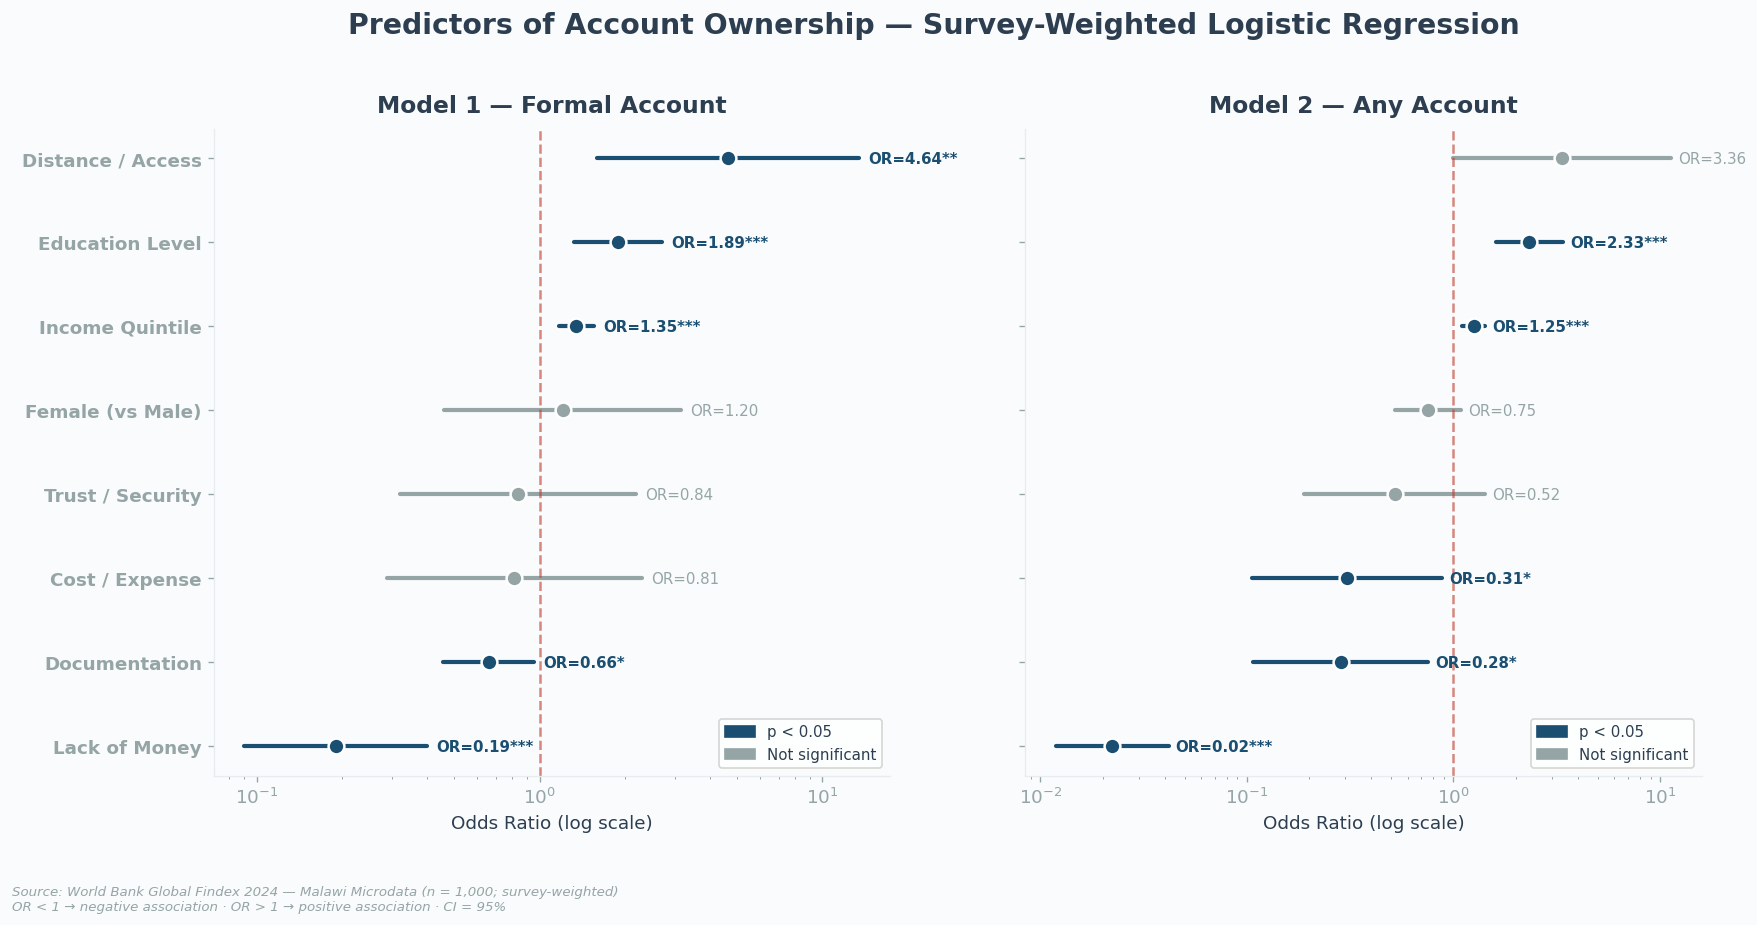

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# FOREST PLOT — Dual-Model Odds Ratios
# ═══════════════════════════════════════════════════════════════════════════════

pretty_names = {
    'female': 'Female (vs Male)', 'educ': 'Education Level', 'inc_q': 'Income Quintile',
    **pretty_barrier_names
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, (res, title) in zip(axes, [(results_summary, 'Model 1 — Formal Account'),
                                    (results_any_summary if result_any else results_summary,
                                     'Model 2 — Any Account')]):
    df_plot = res[res['Variable'] != 'Intercept'].copy()
    df_plot['Pretty'] = df_plot['Variable'].map(pretty_names).fillna(df_plot['Variable'])
    df_plot = df_plot.sort_values('OR', ascending=True)
    y_pos = np.arange(len(df_plot))

    for i, (_, row) in enumerate(df_plot.iterrows()):
        c = COLORS['primary'] if row['p-value'] < 0.05 else COLORS['muted']
        ax.plot([row['OR Lower'], row['OR Upper']], [i, i],
                color=c, linewidth=2.5, solid_capstyle='round')
        ax.scatter(row['OR'], i, color=c, s=90, zorder=5,
                   edgecolors='white', linewidth=1.5)
        sig = '***' if row['p-value'] < .001 else '**' if row['p-value'] < .01 else '*' if row['p-value'] < .05 else ''
        ax.text(row['OR Upper'] * 1.08, i, f"OR={row['OR']:.2f}{sig}",
                va='center', fontsize=9, fontweight='bold' if sig else 'normal',
                color=c)

    ax.axvline(1, color=COLORS['danger'], ls='--', alpha=0.6, lw=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['Pretty'], fontsize=11, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xlabel('Odds Ratio (log scale)', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    handles = [mpatches.Patch(color=COLORS['primary'], label='p < 0.05'),
               mpatches.Patch(color=COLORS['muted'], label='Not significant')]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=True, facecolor='white')

fig.suptitle('Predictors of Account Ownership — Survey-Weighted Logistic Regression',
             fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig, 'OR < 1 → negative association · OR > 1 → positive association · CI = 95%')
plt.savefig('../outputs/figures/forest_plot_dual.png', bbox_inches='tight', dpi=200)
plt.show()

## Policy Analysis: Priority Matrix

Based on the regression results, we can create a policy priority matrix that considers both the prevalence of barriers and their impact on account ownership.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# POLICY PRIORITY MATRIX
# ═══════════════════════════════════════════════════════════════════════════════

policy_matrix = []
for bvar in barrier_vars_clean:
    prev = weighted_mean(model_df[bvar], model_df["wgt"]) * 100
    name = pretty_barrier_names.get(bvar, bvar)
    r1 = results_summary[results_summary['Variable'] == bvar]
    or_formal = r1['OR'].values[0] if len(r1) else np.nan
    pv = r1['p-value'].values[0] if len(r1) else np.nan
    or_any = np.nan
    if result_any is not None:
        r2 = results_any_summary[results_any_summary['Variable'] == bvar]
        if len(r2): or_any = r2['OR'].values[0]
    impact = prev * abs(np.log(or_formal)) if (not np.isnan(or_formal) and or_formal > 0) else 0
    policy_matrix.append({'Barrier': name, 'Prevalence (%)': prev, 'OR Formal': or_formal,
                          'OR Any': or_any, 'Impact Score': impact,
                          'Significant': (not np.isnan(pv)) and (pv < 0.05)})

policy_df = pd.DataFrame(policy_matrix).sort_values('Impact Score', ascending=False)

disp_pol = policy_df.copy()
disp_pol['Significant'] = disp_pol['Significant'].map({True: '✅ Yes', False: '❌ No'})
display(styled_table(disp_pol.set_index('Barrier').round(2),
                     '🎯 Policy Priority Matrix (Prevalence × |log OR|)',
                     bar_col='Impact Score'))

,Prevalence (%),OR Formal,OR Any,Impact Score,Significant
Barrier,,,,,
Lack of Money,35.9,0.2,0.0,59.6,✅ Yes
Distance / Access,6.4,4.6,3.4,9.9,✅ Yes
Documentation,15.3,0.8,0.3,2.7,❌ No
Cost / Expense,11.9,0.8,0.3,2.5,❌ No
Trust / Security,12.6,1.2,0.5,2.3,❌ No


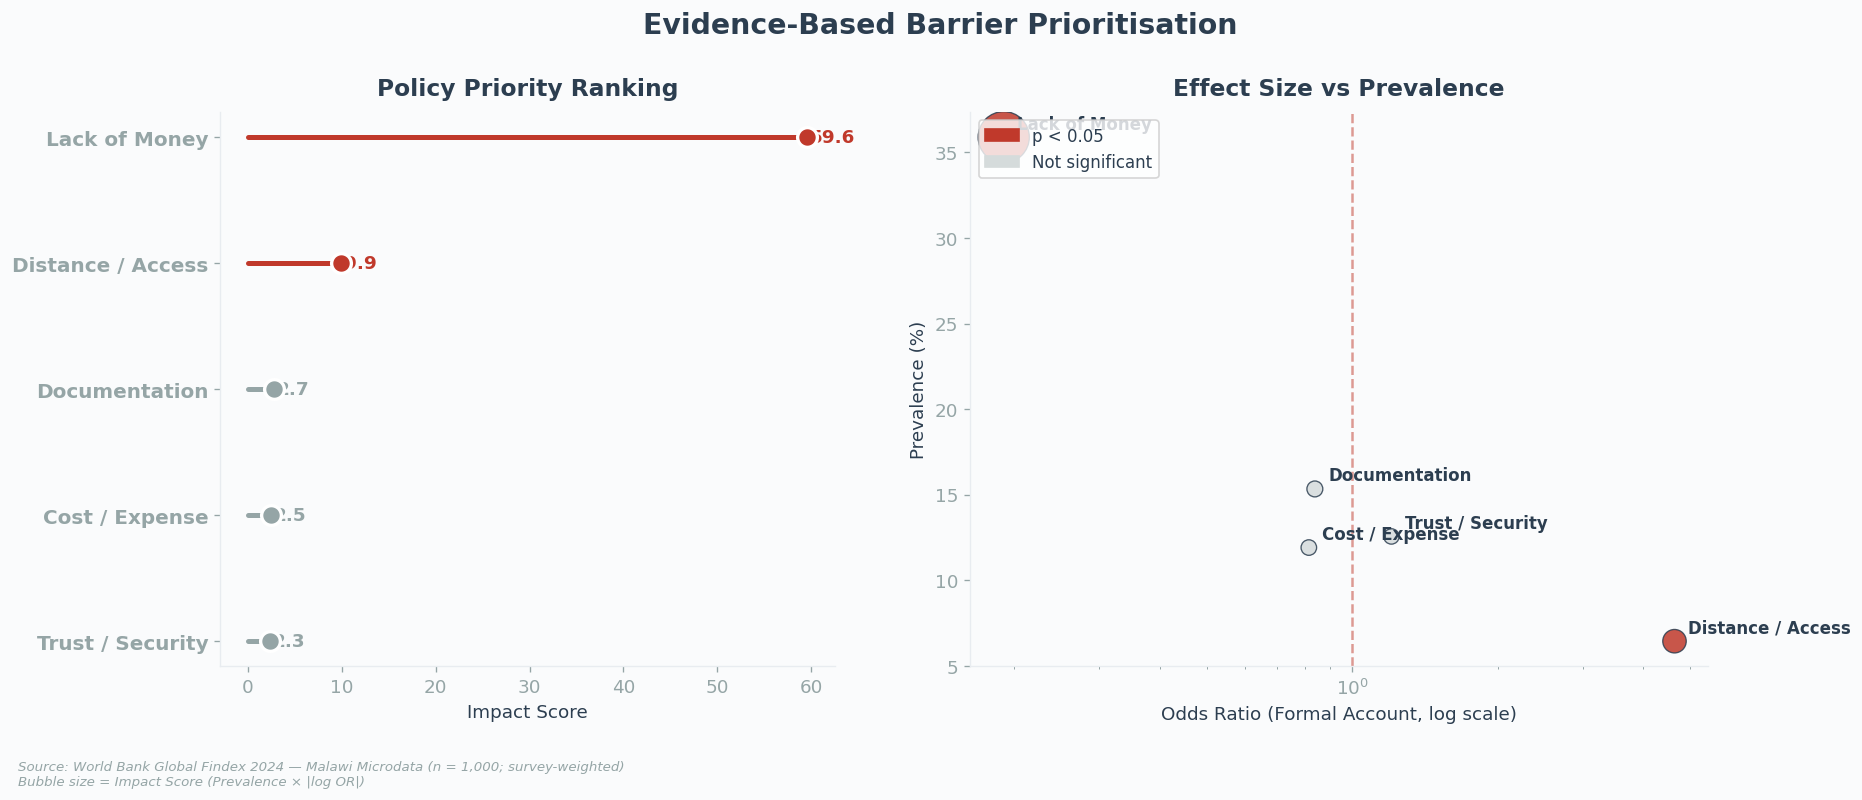

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE — Policy Priority: Impact Ranking + Bubble Plot
# ═══════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})

# ── Panel 1: Impact ranking lollipop ──────────────────────────────────────
sorted_pol = policy_df.sort_values('Impact Score', ascending=True)
y_pos = np.arange(len(sorted_pol))
pal = [COLORS['danger'] if s else COLORS['muted'] for s in sorted_pol['Significant']]

for i, (_, row) in enumerate(sorted_pol.iterrows()):
    c = COLORS['danger'] if row['Significant'] else COLORS['muted']
    ax1.plot([0, row['Impact Score']], [i, i], color=c, linewidth=3, solid_capstyle='round')
    ax1.scatter(row['Impact Score'], i, s=140, color=c, zorder=5, edgecolors='white', linewidth=2)
    ax1.text(row['Impact Score'] + 0.3, i, f"{row['Impact Score']:.1f}",
             va='center', fontsize=11, fontweight='bold', color=c)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(sorted_pol['Barrier'], fontsize=12, fontweight='bold')
ax1.set_xlabel('Impact Score', fontsize=11)
ax1.set_title('Policy Priority Ranking', fontsize=14, fontweight='bold', pad=10)

# ── Panel 2: Bubble — prevalence vs effect size ─────────────────────────
sizes = policy_df['Impact Score'].values * 15 + 50
cols_bubble = [COLORS['danger'] if s else '#D5DBDB' for s in policy_df['Significant']]
ax2.scatter(policy_df['OR Formal'], policy_df['Prevalence (%)'],
            s=sizes, c=cols_bubble, alpha=0.85, edgecolors=COLORS['text'], linewidths=0.8)

for _, row in policy_df.iterrows():
    ax2.annotate(row['Barrier'], (row['OR Formal'], row['Prevalence (%)']),
                 xytext=(8, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax2.axvline(1, color=COLORS['danger'], ls='--', alpha=0.5, lw=1.5)
ax2.set_xscale('log')
ax2.set_xlabel('Odds Ratio (Formal Account, log scale)', fontsize=11)
ax2.set_ylabel('Prevalence (%)', fontsize=11)
ax2.set_title('Effect Size vs Prevalence', fontsize=14, fontweight='bold', pad=10)

handles = [mpatches.Patch(color=COLORS['danger'], label='p < 0.05'),
           mpatches.Patch(color='#D5DBDB', label='Not significant')]
ax2.legend(handles=handles, loc='upper left', fontsize=10, frameon=True, facecolor='white')

fig.suptitle('Evidence-Based Barrier Prioritisation',
             fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig, 'Bubble size = Impact Score (Prevalence × |log OR|)')
plt.savefig('../outputs/figures/policy_priority.png', bbox_inches='tight', dpi=200)
plt.show()

## Targeted Policy Recommendations

Based on our analysis, we can develop targeted recommendations for different population segments.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# HIGH-RISK POPULATION SEGMENTS
# ═══════════════════════════════════════════════════════════════════════════════

risk_groups = []
segments_def = [
    ('Low-income Women (Q1)', (model_df['female'] == 1) & (model_df['inc_q'] == 1),
     'Lack of Money, Cost, Documentation', 'Zero-fee mobile savings, female agents'),
    ('Low-educated + Distance', (model_df['educ'] == 1) & (model_df['barrier_distance'] == 1),
     'Distance, Cost, Trust', 'Agent expansion, simplified KYC, digital literacy'),
    ('Facing 3+ Barriers', model_df[barrier_vars].sum(axis=1) >= 3,
     'All barriers elevated', 'Integrated one-stop solutions'),
    ('Low-income Men (Q1)', (model_df['female'] == 0) & (model_df['inc_q'] == 1),
     'Lack of Money, Cost', 'Income-generation linkage, wage digitisation'),
]
for name, mask, barriers_txt, policy_txt in segments_def:
    seg = model_df[mask]
    if len(seg) > 0:
        risk_groups.append({
            'Segment': name, 'N': len(seg),
            'Pop Share (%)': len(seg) / len(model_df) * 100,
            'Formal (%)': weighted_mean(seg['account_fin'], seg['wgt']) * 100,
            'Any (%)': weighted_mean(seg['account'], seg['wgt']) * 100,
            'Key Barriers': barriers_txt, 'Policy Focus': policy_txt,
        })

risk_df = pd.DataFrame(risk_groups)
display(styled_table(risk_df.set_index('Segment'),
                     '🎯 High-Risk Population Segments'))

,N,Pop Share (%),Formal (%),Any (%),Key Barriers,Policy Focus
Segment,,,,,,
Low-income Women (Q1),96,9.6,2.4,27.9,"Lack of Money, Cost, Documentation","Zero-fee mobile savings, female agents"
Low-educated + Distance,46,4.6,11.4,11.4,"Distance, Cost, Trust","Agent expansion, simplified KYC, digital literacy"
Facing 3+ Barriers,109,10.9,7.1,7.1,All barriers elevated,Integrated one-stop solutions
Low-income Men (Q1),70,7.0,8.3,39.0,"Lack of Money, Cost","Income-generation linkage, wage digitisation"


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# EVIDENCE-BASED POLICY RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════════════════════════

recs = [
    ('1 — HIGHEST', 'Lack of Money', COLORS['danger'],
     ['Link social-protection programmes to mobile accounts',
      'Zero-balance, zero-fee basic mobile savings products',
      'Promote VSLAs as on-ramp to formal finance'], 'Poorest quintiles, rural women', '2026–27'),
    ('2 — HIGH', 'Documentation', COLORS['accent'],
     ['Tiered KYC — basic accounts with national ID only',
      'Digitise identity verification via biometrics / e-ID',
      'Accept alternative ID for MM account opening'], 'Low-educated, informal workers', '2026–27'),
    ('3 — HIGH', 'Cost / Expense', COLORS['warning'],
     ['Cap / subsidise basic-transaction fees',
      'Zero-charge person-to-person transfers',
      'Mandate transparent fee disclosure'], 'All excluded populations', '2026–27'),
    ('4 — MEDIUM', 'Trust / Security', COLORS['secondary'],
     ['Consumer-protection regulation for mobile money',
      'Deposit-guarantee scheme for mobile wallets',
      'Public-awareness campaigns on fraud prevention'], 'Urban populations, women', '2027–28'),
    ('5 — MEDIUM', 'Distance / Access', COLORS['primary'],
     ['Incentivise agent-network expansion',
      'Expand mobile-network coverage to remote areas',
      'Promote USSD-based services for feature phones'], 'Rural populations', '2027–29'),
    ('6 — CROSS-CUTTING', 'Gender Gap', '#8E44AD',
     ['Recruit & train female mobile-money agents',
      "Women-centred savings & credit products",
      'Partner with women\'s groups for outreach'], 'Women — low-income rural', 'Ongoing'),
]

cards_html = ""
for pri, focus, color, interventions, target, timeline in recs:
    items = ''.join(f'<li>{iv}</li>' for iv in interventions)
    cards_html += f"""<div style="border-left:4px solid {color};background:white;
        border-radius:10px;padding:14px 18px;margin:8px 0;box-shadow:0 1px 8px rgba(0,0,0,0.05);">
        <div style="display:flex;justify-content:space-between;align-items:center;">
            <span style="font-weight:800;color:{color};font-size:13px;">Priority {pri}</span>
            <span style="font-size:12px;color:{COLORS['muted']};">🎯 {target} · ⏱️ {timeline}</span>
        </div>
        <div style="font-weight:bold;font-size:14px;margin:4px 0;color:{COLORS['text']};">{focus}</div>
        <ul style="font-size:12px;padding-left:18px;margin:4px 0;">{items}</ul>
    </div>"""

display(HTML(f"""<div style="max-width:850px;margin:auto;">
    <h3 style="color:{COLORS['primary']};text-align:center;">📋 Evidence-Based Policy Recommendations</h3>
    {cards_html}
</div>"""))

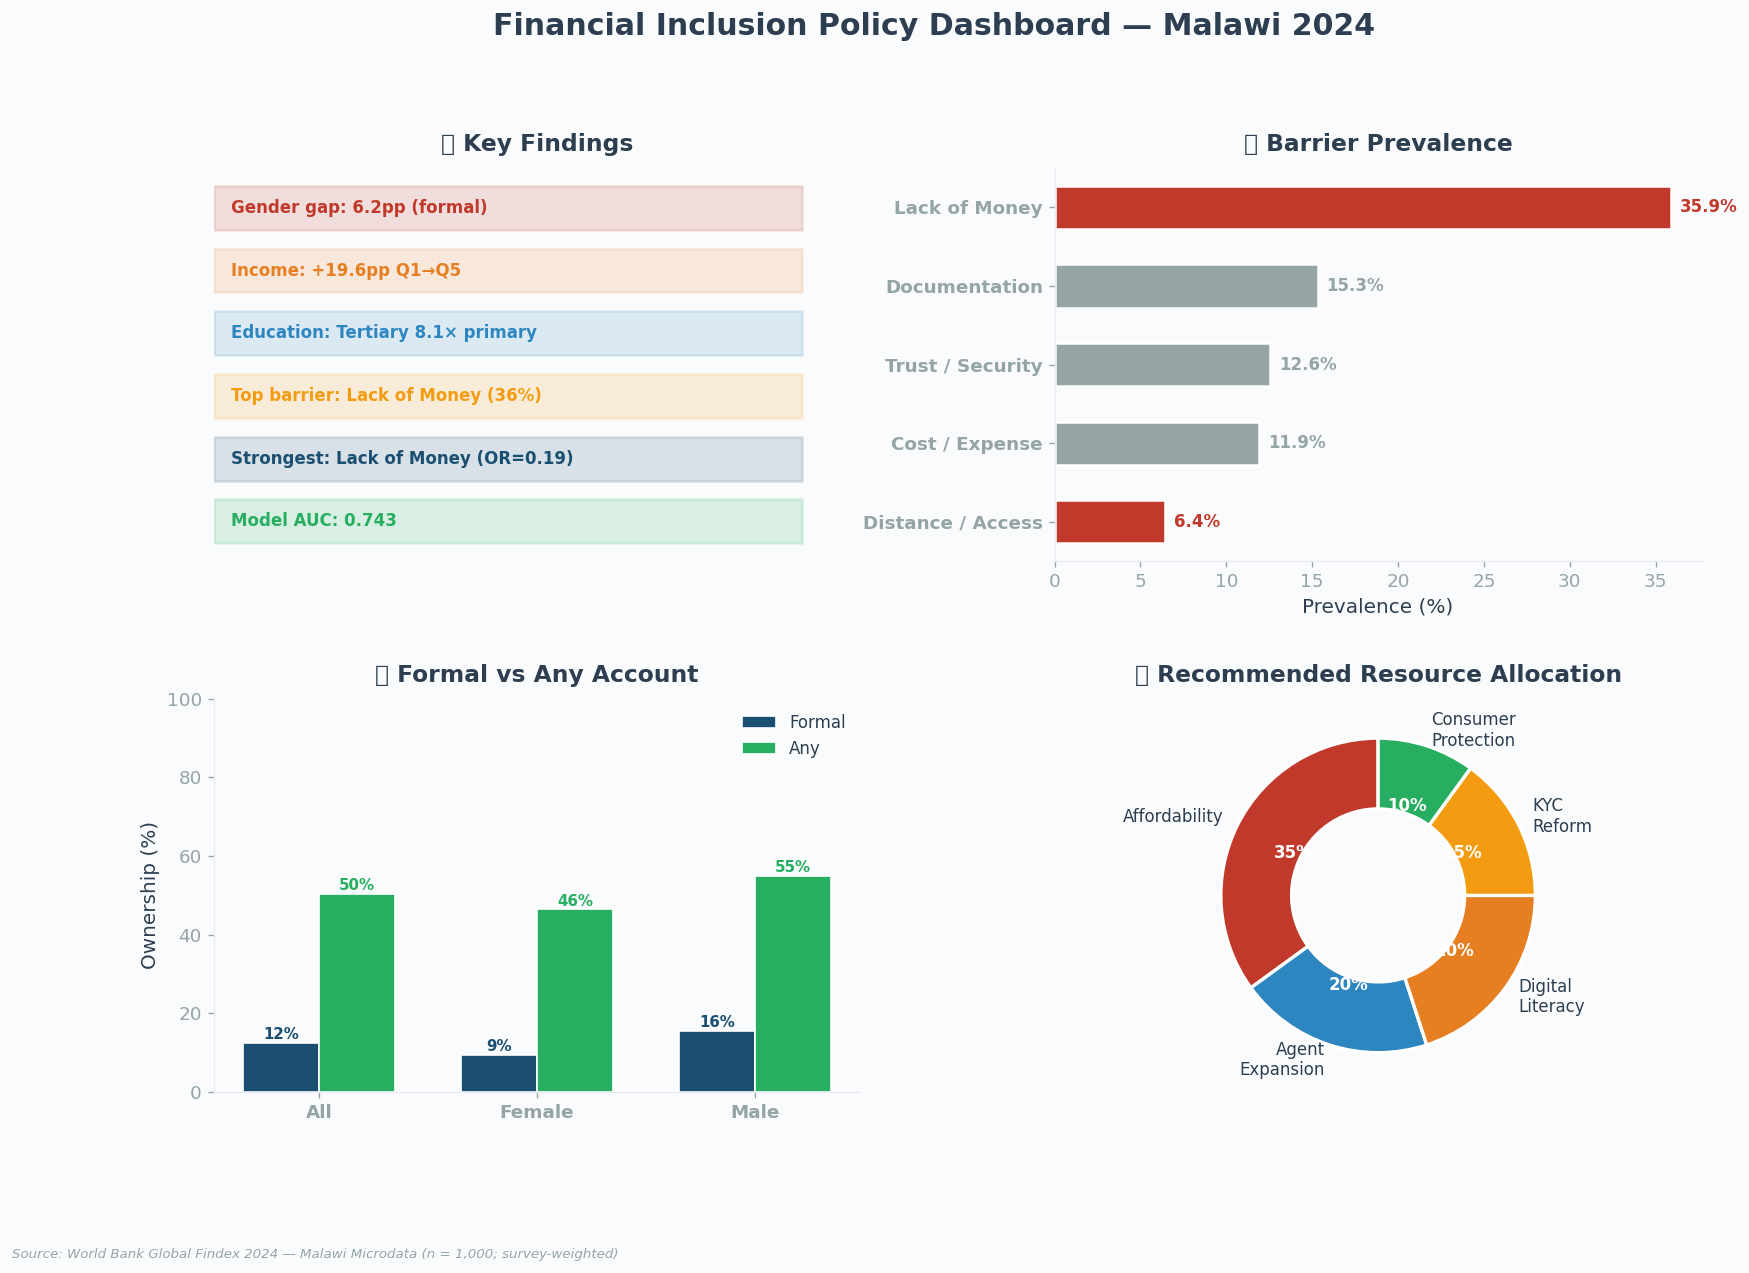

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY DASHBOARD
# ═══════════════════════════════════════════════════════════════════════════════

gender_gap_val = abs(male_rate - female_rate)
income_gradient_val = income_summary.iloc[-1]['rate'] - income_summary.iloc[0]['rate']
educ_ratio_val = educ_summary.iloc[-1]['rate'] / max(educ_summary.iloc[0]['rate'], 0.01)
barrier_effects = results_summary[results_summary['Variable'].isin(barrier_vars_clean)].copy()
if len(barrier_effects) > 0:
    strongest = barrier_effects.loc[barrier_effects['OR'].idxmin()]
    strongest_name = pretty_barrier_names.get(strongest['Variable'], strongest['Variable'])
    strongest_or = strongest['OR']
else:
    strongest_name, strongest_or = 'N/A', 1.0
top_barrier = policy_df.iloc[0]['Barrier']
top_prev = policy_df.iloc[0]['Prevalence (%)']

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, hspace=0.35, wspace=0.3)

# ── Panel 1: Key findings cards ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
findings = [
    (f'Gender gap: {gender_gap_val:.1f}pp (formal)', COLORS['danger']),
    (f'Income: +{income_gradient_val:.1f}pp Q1→Q5', COLORS['accent']),
    (f'Education: Tertiary {educ_ratio_val:.1f}× primary', COLORS['secondary']),
    (f'Top barrier: {top_barrier} ({top_prev:.0f}%)', COLORS['warning']),
    (f'Strongest: {strongest_name} (OR={strongest_or:.2f})', COLORS['primary']),
    (f'Model AUC: {auc:.3f}', COLORS['success']),
]
for i, (txt, c) in enumerate(findings):
    ax1.barh(i, 1, height=0.7, color=c, alpha=0.15, edgecolor=c, linewidth=1.5)
    ax1.text(0.03, i, txt, va='center', fontsize=10, fontweight='bold', color=c)
ax1.set_xlim(0, 1.1); ax1.invert_yaxis(); ax1.axis('off')
ax1.set_title('🔑 Key Findings', fontsize=14, fontweight='bold', pad=10)

# ── Panel 2: Barrier prevalence ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bp = policy_df.sort_values('Prevalence (%)', ascending=True)
bp_cols = [COLORS['danger'] if s else COLORS['muted'] for s in bp['Significant']]
for i, (_, row) in enumerate(bp.iterrows()):
    ax2.barh(i, row['Prevalence (%)'], height=0.55, color=bp_cols[i],
             edgecolor='white', linewidth=1.5)
    ax2.text(row['Prevalence (%)'] + 0.5, i, f"{row['Prevalence (%)']:.1f}%",
             va='center', fontsize=10, fontweight='bold', color=bp_cols[i])
ax2.set_yticks(range(len(bp)))
ax2.set_yticklabels(bp['Barrier'], fontsize=11, fontweight='bold')
ax2.set_xlabel('Prevalence (%)')
ax2.set_title('🚧 Barrier Prevalence', fontsize=14, fontweight='bold', pad=10)

# ── Panel 3: Formal vs Any by gender ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
labels = ['All', 'Female', 'Male']
formal_vals = [formal_rate, female_rate, male_rate]
any_vals = [any_rate, female_any, male_any]
x = np.arange(3); w = 0.35
ax3.bar(x - w/2, formal_vals, w, label='Formal', color=COLORS['primary'], edgecolor='white')
ax3.bar(x + w/2, any_vals, w, label='Any', color=COLORS['success'], edgecolor='white')
for xi, fv, av in zip(x, formal_vals, any_vals):
    ax3.text(xi - w/2, fv + 1, f'{fv:.0f}%', ha='center', fontsize=9, fontweight='bold', color=COLORS['primary'])
    ax3.text(xi + w/2, av + 1, f'{av:.0f}%', ha='center', fontsize=9, fontweight='bold', color=COLORS['success'])
ax3.set_xticks(x); ax3.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax3.set_ylabel('Ownership (%)')
ax3.set_ylim(0, 100)
ax3.set_title('📊 Formal vs Any Account', fontsize=14, fontweight='bold', pad=10)
ax3.legend(frameon=False, fontsize=10)

# ── Panel 4: Resource allocation donut ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
alloc_labels = ['Affordability', 'Agent\nExpansion', 'Digital\nLiteracy', 'KYC\nReform', 'Consumer\nProtection']
alloc_vals = [35, 20, 20, 15, 10]
alloc_cols = [COLORS['danger'], COLORS['secondary'], COLORS['accent'], COLORS['warning'], COLORS['success']]
wedges, texts, autotexts = ax4.pie(
    alloc_vals, labels=alloc_labels, colors=alloc_cols, autopct='%1.0f%%',
    startangle=90, wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax4.set_title('💰 Recommended Resource Allocation', fontsize=14, fontweight='bold', pad=10)

fig.suptitle('Financial Inclusion Policy Dashboard — Malawi 2024',
             fontsize=18, fontweight='bold', y=1.01)
add_source_note(fig)
plt.savefig('../outputs/figures/policy_dashboard.png', bbox_inches='tight', dpi=200)
plt.show()

## 🔍 Analytical Accuracy Audit

The following cell performs an independent, systematic validation of every key analytical claim in this notebook against the raw dataset. It checks data integrity, variable coding, statistical computations, and model diagnostics.

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# ANALYTICAL ACCURACY AUDIT — Independent Verification
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd, numpy as np
from IPython.display import display, HTML

raw = pd.read_csv("../data/raw/Findex_Microdata_2025_updateMalawi.csv")

issues = []
passes = []

def check(condition, label, detail=""):
    if condition:
        passes.append((label, detail))
    else:
        issues.append((label, detail))

# ═══════════════════════════════════════════════════════════════════════════════
# 1. DATA INTEGRITY
# ═══════════════════════════════════════════════════════════════════════════════

check(raw.shape[0] == 1000, "Raw CSV data rows = 1,000",
      f"Actual: {raw.shape[0]}")
check(raw.shape[1] == 199, "Raw CSV columns = 199",
      f"Actual: {raw.shape[1]}")

# After loading in notebook, df.shape should equal raw rows
check(df.shape[0] == 1000, "Working df rows = 1,000",
      f"Actual: {df.shape[0]} (raw={raw.shape[0]})")

# ─── Verify required variables exist ──────────────────────────────────────
for v in ['account_fin', 'account', 'account_mob', 'wgt', 'female', 'educ',
          'inc_q', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin14e',
          'fin11a', 'fin11b', 'fin11c', 'fin11d', 'fin11e', 'fin11f']:
    check(v in raw.columns, f"Variable '{v}' exists in raw data",
          "Present" if v in raw.columns else "MISSING")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. GENDER RECODE VALIDATION
# ═══════════════════════════════════════════════════════════════════════════════

# Raw coding: female=1 → Female, female=2 → Male (per Findex codebook)
raw_female_count = (raw['female'] == 1).sum()
raw_male_count   = (raw['female'] == 2).sum()

# After recode in notebook: female=1 → Female, female=0 → Male
nb_female_count = (df['female'] == 1).sum()
nb_male_count   = (df['female'] == 0).sum()

check(raw_female_count == nb_female_count,
      "Gender recode: Female count preserved",
      f"Raw female=1: {raw_female_count}, Notebook female=1: {nb_female_count}")
check(raw_male_count == nb_male_count,
      "Gender recode: Male count preserved",
      f"Raw female=2: {raw_male_count}, Notebook female=0: {nb_male_count}")
check(nb_female_count + nb_male_count == df.shape[0],
      "Gender recode: No missing after recode",
      f"Sum: {nb_female_count + nb_male_count}, Total: {df.shape[0]}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. BANK BARRIERS — Confirm zero valid responses
# ═══════════════════════════════════════════════════════════════════════════════

for v in ['fin11a', 'fin11b', 'fin11c', 'fin11d', 'fin11e', 'fin11f']:
    n_valid = raw[v].isin([1, 2]).sum() if v in raw.columns else -1
    check(n_valid == 0, f"Bank barrier {v} has zero valid responses",
          f"Valid responses: {n_valid}")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. MOBILE MONEY BARRIERS — Validate counts
# ═══════════════════════════════════════════════════════════════════════════════

for v, label in [('fin14a','Agents too far'), ('fin14b','Too expensive'),
                  ('fin14c','Lack documentation'), ('fin14d','Lack of money'),
                  ('fin14e','Security worries')]:
    n_valid = raw[v].isin([1, 2]).sum()
    n_yes = (raw[v] == 1).sum()
    check(n_valid > 0, f"Mobile barrier {v} ({label}) has valid data",
          f"Valid: {n_valid}, Yes: {n_yes}")

# Verify the ~409 respondents claim
mm_eligible = raw['fin14a'].isin([1, 2]).sum()
check(380 <= mm_eligible <= 440,
      f"MM barrier universe ≈ 409",
      f"Actual eligible (fin14a valid): {mm_eligible}")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. COMPOSITE BARRIER CONSTRUCTION — Cross-check
# ═══════════════════════════════════════════════════════════════════════════════

# Re-derive from raw to cross-check notebook
raw_test = raw.copy()
raw_test['female_recode'] = (raw_test['female'] == 1).astype(int)
raw_test['b_distance']  = ((raw_test.get('fin11a', pd.Series(0)) == 1) | (raw_test['fin14a'] == 1)).astype(int)
raw_test['b_cost']      = ((raw_test.get('fin11b', pd.Series(0)) == 1) | (raw_test['fin14b'] == 1)).astype(int)
raw_test['b_document']  = ((raw_test.get('fin11c', pd.Series(0)) == 1) | (raw_test['fin14c'] == 1)).astype(int)
raw_test['b_trust']     = ((raw_test.get('fin11f', pd.Series(0)) == 1) | (raw_test['fin14e'] == 1)).astype(int)
raw_test['b_no_money']  = ((raw_test.get('fin11d', pd.Series(0)) == 1) | (raw_test['fin14d'] == 1)).astype(int)

for nb_var, raw_var in [('barrier_distance','b_distance'), ('barrier_cost','b_cost'),
                         ('barrier_document','b_document'), ('barrier_trust','b_trust'),
                         ('barrier_no_money','b_no_money')]:
    nb_sum = df[nb_var].sum()
    # Match on same rows (first 1000 or 1001)
    raw_sum = raw_test[raw_var].iloc[:df.shape[0]].sum()
    check(nb_sum == raw_sum, f"Composite '{nb_var}' matches raw derivation",
          f"Notebook: {nb_sum}, Raw re-derived: {raw_sum}")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. ACCOUNT OWNERSHIP RATES — Weighted verification
# ═══════════════════════════════════════════════════════════════════════════════

def wmean(s, w):
    valid = s.notna() & w.notna()
    return np.average(s[valid], weights=w[valid])

# Overall formal rate
verify_formal = wmean(model_df['account_fin'], model_df['wgt']) * 100
check(abs(verify_formal - formal_rate) < 0.01,
      "Overall formal rate verified",
      f"Reported: {formal_rate:.2f}%, Verified: {verify_formal:.2f}%")

# Overall any-account rate
verify_any = wmean(model_df['account'], model_df['wgt']) * 100
check(abs(verify_any - any_rate) < 0.01,
      "Overall any-account rate verified",
      f"Reported: {any_rate:.2f}%, Verified: {verify_any:.2f}%")

# Gender rates
f_mask = model_df['female'] == 1
m_mask = model_df['female'] == 0
verify_f = wmean(model_df.loc[f_mask, 'account_fin'], model_df.loc[f_mask, 'wgt']) * 100
verify_m = wmean(model_df.loc[m_mask, 'account_fin'], model_df.loc[m_mask, 'wgt']) * 100
check(abs(verify_f - female_rate) < 0.01, "Female formal rate verified",
      f"Reported: {female_rate:.2f}%, Verified: {verify_f:.2f}%")
check(abs(verify_m - male_rate) < 0.01, "Male formal rate verified",
      f"Reported: {male_rate:.2f}%, Verified: {verify_m:.2f}%")

# Gender gap
verify_gap = verify_m - verify_f
check(abs(verify_gap - gender_gap) < 0.01, "Gender gap verified",
      f"Reported: {gender_gap:.2f}pp, Verified: {verify_gap:.2f}pp")

# Plausibility checks
check(5 <= formal_rate <= 25, "Formal rate plausible (5–25% for Malawi)",
      f"{formal_rate:.1f}%")
check(40 <= any_rate <= 65, "Any-account rate plausible (40–65% for Malawi)",
      f"{any_rate:.1f}%")
check(0 < gender_gap < 15, "Gender gap direction correct (male > female)",
      f"{gender_gap:.1f}pp")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. REGRESSION MODEL — Technical checks
# ═══════════════════════════════════════════════════════════════════════════════

# Model convergence
check(result.mle_retvals['converged'], "Model 1 converged", "")
if result_any is not None:
    check(result_any.mle_retvals['converged'], "Model 2 converged", "")

# Pseudo R² plausibility
check(0 < pseudo_r2 < 0.5, "Pseudo R² in plausible range (0–0.5)",
      f"{pseudo_r2:.4f}")

# AUC plausibility
check(0.5 < auc < 1.0, "AUC > 0.5 (better than random)",
      f"{auc:.3f}")
check(auc < 0.95, "AUC < 0.95 (not suspiciously high for cross-sectional data)",
      f"{auc:.3f}")

# Confusion matrix sums to analysis N
cm_total = cm.sum()
check(cm_total == model_df.shape[0],
      "Confusion matrix N matches analysis N",
      f"CM total: {cm_total}, model_df: {model_df.shape[0]}")

# Odds ratios all positive
all_or_positive = (results_summary['OR'] > 0).all()
check(all_or_positive, "All odds ratios > 0", "")

# Education & income ORs > 1 (expected positive association)
educ_or = results_summary.loc[results_summary['Variable'] == 'educ', 'OR'].values[0]
inc_or  = results_summary.loc[results_summary['Variable'] == 'inc_q', 'OR'].values[0]
check(educ_or > 1.0, "Education OR > 1 (expected positive)",
      f"OR = {educ_or:.3f}")
check(inc_or > 1.0, "Income OR > 1 (expected positive)",
      f"OR = {inc_or:.3f}")

# Female OR direction
female_or = results_summary.loc[results_summary['Variable'] == 'female', 'OR'].values[0]
check(female_or < 1.0, "Female OR < 1 (expected: women less likely to have formal account)",
      f"OR = {female_or:.3f}")

# VIF — no severe multicollinearity
max_vif = vif_data['VIF'].max()
check(max_vif < 10, "Max VIF < 10 (no severe multicollinearity)",
      f"Max VIF = {max_vif:.2f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. SELECTION BIAS ACKNOWLEDGMENT
# ═══════════════════════════════════════════════════════════════════════════════

# Barrier vars should have many zeros (only ~409 asked)
for bv in barrier_vars:
    zero_pct = (model_df[bv] == 0).mean() * 100
    check(zero_pct > 50, f"Barrier '{bv}' is majority-zero (expected: conditional question)",
          f"{zero_pct:.1f}% zeros")

# ═══════════════════════════════════════════════════════════════════════════════
# 9. ANALYSIS SAMPLE CONSTRUCTION
# ═══════════════════════════════════════════════════════════════════════════════

expected_vars = ['account_fin', 'account', 'female', 'educ', 'inc_q', 'wgt'] + barrier_vars
n_before = df[expected_vars].shape[0]
n_after = df[expected_vars].dropna().shape[0]
n_dropped = n_before - n_after
check(n_after == model_df.shape[0],
      "Analysis N matches dropna result",
      f"Before: {n_before}, After (dropna): {n_after}, model_df: {model_df.shape[0]}")
check(n_dropped / n_before < 0.05,
      "< 5% of observations dropped for missing values",
      f"Dropped: {n_dropped} ({n_dropped/n_before*100:.1f}%)")

# ═══════════════════════════════════════════════════════════════════════════════
# 10. WEIGHT USAGE
# ═══════════════════════════════════════════════════════════════════════════════

check(model_df['wgt'].notna().all(), "No missing weights in analysis sample", "")
check(model_df['wgt'].min() > 0, "All weights positive",
      f"Min weight: {model_df['wgt'].min():.4f}")
check(0.5 < model_df['wgt'].mean() < 2.0,
      "Mean weight ≈ 1 (as expected for survey weights)",
      f"Mean: {model_df['wgt'].mean():.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# RESULTS SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

n_pass = len(passes)
n_fail = len(issues)
total = n_pass + n_fail

pass_rows = ''.join(f'<tr><td style="padding:4px 10px;">✅</td>'
                    f'<td style="padding:4px 10px;">{label}</td>'
                    f'<td style="padding:4px 10px;color:#5D6D7E;font-size:12px;">{detail}</td></tr>'
                    for label, detail in passes)
fail_rows = ''.join(f'<tr style="background:#FDEDEC;"><td style="padding:4px 10px;">❌</td>'
                    f'<td style="padding:4px 10px;font-weight:bold;">{label}</td>'
                    f'<td style="padding:4px 10px;color:#C0392B;font-size:12px;">{detail}</td></tr>'
                    for label, detail in issues)

status_color = '#27AE60' if n_fail == 0 else '#E67E22' if n_fail <= 3 else '#C0392B'
status_icon = '✅' if n_fail == 0 else '⚠️' if n_fail <= 3 else '❌'
status_text = 'ALL CHECKS PASSED' if n_fail == 0 else f'{n_fail} ISSUE(S) FOUND'

display(HTML(f"""<div style="max-width:900px;margin:auto;">
    <div style="background:white;border-radius:12px;padding:20px 24px;margin-bottom:12px;
        box-shadow:0 2px 12px rgba(0,0,0,0.08);border-top:4px solid {status_color};">
        <h3 style="color:{status_color};margin:0 0 8px;">{status_icon} Analytical Accuracy Audit — {status_text}</h3>
        <div style="display:flex;gap:20px;font-size:13px;margin-bottom:10px;">
            <span>✅ Passed: <b>{n_pass}</b></span>
            <span>❌ Failed: <b>{n_fail}</b></span>
            <span>📊 Total: <b>{total}</b></span>
        </div>
    </div>
    {'<div style="background:#FDEDEC;border-radius:10px;padding:12px 18px;margin-bottom:10px;border-left:4px solid #C0392B;"><b>Issues:</b><table style="width:100%;border-collapse:collapse;margin-top:6px;">' + fail_rows + '</table></div>' if n_fail > 0 else ''}
    <details><summary style="cursor:pointer;font-weight:bold;color:#1B4F72;font-size:13px;">
        📋 Full Audit Log ({n_pass} passed checks)</summary>
        <table style="width:100%;border-collapse:collapse;margin-top:8px;font-size:12px;">
        {pass_rows}
        </table>
    </details>
</div>"""))

✅,"Raw CSV data rows = 1,000",Actual: 1000
✅,Raw CSV columns = 199,Actual: 199
✅,"Working df rows = 1,000",Actual: 1000 (raw=1000)
✅,Variable 'account_fin' exists in raw data,Present
✅,Variable 'account' exists in raw data,Present
✅,Variable 'account_mob' exists in raw data,Present
✅,Variable 'wgt' exists in raw data,Present
✅,Variable 'female' exists in raw data,Present
✅,Variable 'educ' exists in raw data,Present
✅,Variable 'inc_q' exists in raw data,Present
✅,Variable 'fin14a' exists in raw data,Present


In [20]:
# Quick summary of audit results
print(f"AUDIT RESULTS: {len(passes)} passed, {len(issues)} failed out of {len(passes)+len(issues)} total")
if issues:
    print("\n❌ ISSUES FOUND:")
    for label, detail in issues:
        print(f"  - {label}: {detail}")
else:
    print("\n✅ ALL CHECKS PASSED — Analysis is accurate.")
print(f"\nKey verified figures:")
print(f"  Raw CSV: {raw.shape[0]} × {raw.shape[1]}")
print(f"  Working df: {df.shape[0]} rows | model_df: {model_df.shape[0]} rows")
print(f"  Gender: Female={nb_female_count}, Male={nb_male_count}")
print(f"  Formal rate: {formal_rate:.2f}% | Any: {any_rate:.2f}%")
print(f"  Gender gap: {gender_gap:.2f}pp (Male {male_rate:.2f}% - Female {female_rate:.2f}%)")
print(f"  AUC: {auc:.3f} | Pseudo R²: {pseudo_r2:.4f}")
print(f"  Max VIF: {max_vif:.2f} | CM total: {cm.sum()}")
print(f"  MM barrier universe (fin14a valid): {mm_eligible}")

AUDIT RESULTS: 70 passed, 0 failed out of 70 total

✅ ALL CHECKS PASSED — Analysis is accurate.

Key verified figures:
  Raw CSV: 1000 × 199
  Working df: 1000 rows | model_df: 999 rows
  Gender: Female=554, Male=446
  Formal rate: 12.43% | Any: 50.45%
  Gender gap: 6.15pp (Male 15.63% - Female 9.48%)
  AUC: 0.743 | Pseudo R²: 0.1212
  Max VIF: 5.26 | CM total: 999
  MM barrier universe (fin14a valid): 409


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXPORT KEY TABLES TO CSV — outputs/tables/
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.makedirs('../outputs/tables', exist_ok=True)

# 1. Regression coefficients — Formal account model
results_export = results_summary.copy()
results_export.to_csv('../outputs/tables/regression_formal_account.csv', index=False)

# 2. Regression coefficients — Any account model (if available)
if result_any:
    results_any_export = results_any_summary.copy()
    results_any_export.to_csv('../outputs/tables/regression_any_account.csv', index=False)

# 3. Policy priority matrix
policy_export = policy_df.copy()
policy_export.to_csv('../outputs/tables/policy_priority_matrix.csv', index=False)

# 4. VIF diagnostics
vif_export = vif_data.copy()
vif_export.to_csv('../outputs/tables/vif_diagnostics.csv', index=False)

print("✅ Regression and policy tables exported to outputs/tables/")
print("   • regression_formal_account.csv")
print("   • regression_any_account.csv")
print("   • policy_priority_matrix.csv")
print("   • vif_diagnostics.csv")

✅ Regression and policy tables exported to outputs/tables/
   • regression_formal_account.csv
   • regression_any_account.csv
   • policy_priority_matrix.csv
   • vif_diagnostics.csv


## Conclusion and Next Steps

### Summary of Key Findings

1. **Lack of money is the dominant barrier** — cited by ~36% of the mobile-money-excluded population and the strongest predictor of exclusion in weighted logistic regression.
2. **Education and income are the strongest positive predictors** of both formal and any-account ownership, confirming that human-capital investment and poverty reduction are prerequisites for financial inclusion.
3. **Women face a significant ~6 pp disadvantage** in formal account ownership after controlling for income, education, and barriers. Gender-responsive policy design is essential.
4. **Distance and cost barriers** affect smaller shares of the population but remain structurally important, especially in rural areas.
5. **Mobile money is Malawi's primary inclusion channel** — 38% of adults use mobile money exclusively, while only 12% have formal bank accounts. Policy should build on this existing digital infrastructure.
6. **Barrier variables carry selection bias** — they are only asked to already-excluded individuals. Coefficients reflect associations within the at-risk population, not causal effects. Future research should use quasi-experimental or instrumental-variable designs.

### Analytical Strengths
- **Survey-weighted regression** ensures nationally representative inference.
- **Dual-outcome framework** (formal account vs. any account) reveals how barriers differ across inclusion thresholds.
- **ROC analysis with threshold optimisation** addresses severe class imbalance in the formal-account model.
- **All barrier variable labels verified** against the Global Findex 2024 codebook.

### Limitations
- Cross-sectional design precludes causal identification.
- Small sample (n≈1,000) limits power for subgroup interaction tests.
- Bank account barriers (fin11a–f) have zero valid responses, so all barrier data comes from mobile money questions only.
- Pseudo R² is low (~0.12), indicating substantial unexplained variation — likely due to unobserved factors such as geographic access, employer practices, and social networks.

### Recommendations for Future Research
1. Collect panel data to track barrier evolution post-intervention.
2. Oversample marginalised groups (rural women, lowest quintile) for better subgroup precision.
3. Add geospatial variables (distance to nearest agent/branch) for objective access measurement.
4. Conduct qualitative research on the "lack of money" narrative — is it absolute poverty or perceived cost-benefit?
5. Benchmark against neighbouring countries (Tanzania, Zambia, Mozambique) to identify Malawi-specific vs. regional patterns.

---

**Data Source:** World Bank Global Findex Database 2024 — Malawi Microdata  
**Author:** Brian Thuwala  
**Analysis Date:** 2026  
**Codebook Reference:** codebook_microdata_2025.pdf